In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


# **Improving Robustness of Reinforcement Learning for Autonomous Driving Under Sensor Noise and Partial Observability**

Graduate Reinforcement Learning Final Project

Authors:
Basetti Sai Viswas  
Danalakota Satya Ganga Sree Govinda Nandini  
Kanika

# 1. Project Overview

This project investigates the robustness of PPO and Recurrent PPO under noisy observations and partial observability in autonomous driving environments.

Research Questions:
1. How robust is PPO under sensor noise?
2. How does observation occlusion affect performance?
3. Can recurrent policies improve robustness under partial observability?

In [ ]:
!pip install highway-env stable-baselines3 sb3-contrib gymnasium matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 12.3 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


# 2. Environment Setup and Utilities

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
import highway_env

from stable_baselines3 import PPO, DQN
from sb3_contrib import RecurrentPPO

from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Create folders**

In [ ]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("videos", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


**Reward logger**

In [ ]:
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.rewards = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.rewards.append(info["episode"]["r"])
        return True

**Environment wrappers**

In [ ]:
class EcoDrivingWrapper(gym.Wrapper):
    def __init__(self, env, penalty=0.05):
        super().__init__(env)
        self.penalty = penalty

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        eco_penalty = 0.0

        # highway-v0 discrete actions:
        # 0 = LANEL_LEFT, 1 = IDLE, 2 = LANE_RIGHT, 3 = FASTER, 4 = SLOWER
        if action in [0, 2, 3]:
            eco_penalty += self.penalty

        reward = reward - eco_penalty

        return obs, reward, terminated, truncated, info


class GaussianNoiseWrapper(gym.ObservationWrapper):
    def __init__(self, env, noise_std=0.03):
        super().__init__(env)
        self.noise_std = noise_std

    def observation(self, obs):
        obs = obs.copy()
        noise = np.random.normal(0, self.noise_std, size=obs.shape)
        return obs + noise


class DropoutNoiseWrapper(gym.ObservationWrapper):
    def __init__(self, env, dropout_prob=0.10):
        super().__init__(env)
        self.dropout_prob = dropout_prob

    def observation(self, obs):
        obs = obs.copy()
        mask = np.random.rand(*obs.shape) < self.dropout_prob
        obs[mask] = 0
        return obs

**Environment creator**

In [ ]:
def make_env(
    env_name="highway-v0",
    eco=False,
    gaussian_noise=False,
    dropout_noise=False,
    noise_std=0.03,
    dropout_prob=0.10
):
    env = gym.make(env_name, render_mode=None)

    # Fast and consistent configuration
    env.unwrapped.config["vehicles_count"] = 10
    env.unwrapped.config["duration"] = 20
    env.unwrapped.config["simulation_frequency"] = 5
    env.unwrapped.config["policy_frequency"] = 1

    if gaussian_noise:
        env = GaussianNoiseWrapper(env, noise_std=noise_std)

    if dropout_noise:
        env = DropoutNoiseWrapper(env, dropout_prob=dropout_prob)

    if eco:
        env = EcoDrivingWrapper(env, penalty=0.05)

    env = Monitor(env)
    return env

**Evaluation functions**

In [ ]:
def evaluate_model(model, env, episodes=10, recurrent=False):
    rewards = []
    collisions = 0
    speeds = []

    for _ in range(episodes):
        obs, _ = env.reset()
        done = False
        episode_reward = 0

        lstm_states = None
        episode_starts = np.ones((1,), dtype=bool)

        while not done:
            if recurrent:
                action, lstm_states = model.predict(
                    obs,
                    state=lstm_states,
                    episode_start=episode_starts,
                    deterministic=True
                )
                episode_starts = np.array([False])
            else:
                action, _ = model.predict(obs, deterministic=True)

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            episode_reward += reward

            try:
                speeds.append(env.unwrapped.vehicle.speed)
            except:
                pass

            if terminated:
                collisions += 1

        rewards.append(episode_reward)

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "collision_rate": collisions / episodes,
        "avg_speed": np.mean(speeds) if len(speeds) > 0 else np.nan
    }

**Training helper**

In [ ]:
def train_ppo(env, timesteps=10000, name="ppo_model"):
    callback = RewardCallback()

    model = PPO(
        "MlpPolicy",
        env,
        verbose=1,
        n_steps=512,
        batch_size=32,
        learning_rate=3e-4,
        device="cpu"
    )

    model.learn(total_timesteps=timesteps, callback=callback)
    model.save(f"models/{name}")

    return model, callback.rewards

**Recurrent PPO training helper**

In [ ]:
def train_recurrent_ppo(env, timesteps=10000, name="recurrent_ppo_model"):
    callback = RewardCallback()

    model = RecurrentPPO(
        "MlpLstmPolicy",
        env,
        verbose=1,
        n_steps=512,
        batch_size=32,
        learning_rate=3e-4,
        device="cpu"
    )

    model.learn(total_timesteps=timesteps, callback=callback)
    model.save(f"models/{name}")

    return model, callback.rewards

# Experiment 1: PPO Baseline

This experiment trains a standard PPO agent on the default highway environment and establishes the baseline performance.

In [ ]:
env_ppo_clean = make_env()

ppo_clean, rewards_ppo_clean = train_ppo(
    env_ppo_clean,
    timesteps=10000,
    name="ppo_clean"
)

results_ppo_clean = evaluate_model(
    ppo_clean,
    env_ppo_clean,
    episodes=10,
    recurrent=False
)

results_ppo_clean

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11.7     |
|    ep_rew_mean     | 9.01     |
| time/              |          |
|    fps             | 28       |
|    iterations      | 1        |
|    time_elapsed    | 18       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 12.9        |
|    ep_rew_mean          | 9.89        |
| time/                   |             |
|    fps                  | 29          |
|    iterations           | 2           |
|    time_elapsed         | 34          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.016509533 |
|    clip_fraction        | 0.195       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | 0.0108      |
|    learning_rate        | 0.0003      |
|    loss                 | 3.48        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0212     |
|    value_loss           | 11.6        |
-----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19.4         |
|    ep_rew_mean          | 13.8         |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 19           |
|    time_elapsed         | 324          |
|    total_timesteps      | 9728         |
| train/                  |              |
|    approx_kl            | 0.0088519845 |
|    clip_fraction        | 0.111        |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.808       |
|    explained_variance   | -4.64e-05    |
|    learning_rate        | 0.0003       |
|    loss                 | 16.8         |
|    n_updates            | 180          |
|    policy_gradient_loss | -0.0078      |
|    value_loss           | 22           |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19.3         |
|    ep_rew_mean          | 13.8         |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 20           |
|    time_elapsed         | 340          |
|    total_timesteps      | 10240        |
| train/                  |              |
|    approx_kl            | 0.0065688835 |
|    clip_fraction        | 0.0506       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.74        |
|    explained_variance   | -0.00409     |
|    learning_rate        | 0.0003       |
|    loss                 | 0.386        |
|    n_updates            | 190          |
|    policy_gradient_loss | -0.00805     |
|    value_loss           | 2.28         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(12.74910997784509),
 'std_reward': np.float64(3.027655485194264),
 'collision_rate': 0.1,
 'avg_speed': np.float64(19.98829544847848)}

# Experiment 2: PPO Under Gaussian Observation Noise

This experiment evaluates the robustness of PPO when Gaussian noise is injected into the observation space.

In [ ]:
env_ppo_noise = make_env(
    gaussian_noise=True,
    noise_std=0.03
)

ppo_noise, rewards_ppo_noise = train_ppo(
    env_ppo_noise,
    timesteps=10000,
    name="ppo_noise"
)

results_ppo_noise = evaluate_model(
    ppo_noise,
    env_ppo_noise,
    episodes=10,
    recurrent=False
)

results_ppo_noise

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11.8     |
|    ep_rew_mean     | 8.98     |
| time/              |          |
|    fps             | 29       |
|    iterations      | 1        |
|    time_elapsed    | 17       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 12.3        |
|    ep_rew_mean          | 9.26        |
| time/                   |             |
|    fps                  | 29          |
|    iterations           | 2           |
|    time_elapsed         | 34          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.011604518 |
|    clip_fraction        | 0.0504      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.0109     |
|    learning_rate        | 0.0003      |
|    loss                 | 3.1         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00885    |
|    value_loss           | 10.1        |
-----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19.1         |
|    ep_rew_mean          | 13.5         |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 19           |
|    time_elapsed         | 321          |
|    total_timesteps      | 9728         |
| train/                  |              |
|    approx_kl            | 0.0053568673 |
|    clip_fraction        | 0.073        |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.689       |
|    explained_variance   | 0.00047      |
|    learning_rate        | 0.0003       |
|    loss                 | 15.8         |
|    n_updates            | 180          |
|    policy_gradient_loss | -0.00744     |
|    value_loss           | 65.7         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19.2         |
|    ep_rew_mean          | 13.6         |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 20           |
|    time_elapsed         | 338          |
|    total_timesteps      | 10240        |
| train/                  |              |
|    approx_kl            | 0.0016704202 |
|    clip_fraction        | 0.0152       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.669       |
|    explained_variance   | -0.00255     |
|    learning_rate        | 0.0003       |
|    loss                 | 0.476        |
|    n_updates            | 190          |
|    policy_gradient_loss | -0.00169     |
|    value_loss           | 12.4         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(13.842443391258552),
 'std_reward': np.float64(0.4192880503136282),
 'collision_rate': 0.0,
 'avg_speed': np.float64(20.03791469194313)}

# Experiment 3: Eco-Driving Reward Shaping

This experiment introduces acceleration and steering penalties to encourage smoother driving behaviour.

In [ ]:
env_ppo_eco_noise = make_env(
    eco=True,
    gaussian_noise=True,
    noise_std=0.03
)

ppo_eco_noise, rewards_ppo_eco_noise = train_ppo(
    env_ppo_eco_noise,
    timesteps=10000,
    name="ppo_eco_noise"
)

results_ppo_eco_noise = evaluate_model(
    ppo_eco_noise,
    env_ppo_eco_noise,
    episodes=10,
    recurrent=False
)

results_ppo_eco_noise

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 13.2     |
|    ep_rew_mean     | 9.65     |
| time/              |          |
|    fps             | 30       |
|    iterations      | 1        |
|    time_elapsed    | 16       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 13.5        |
|    ep_rew_mean          | 9.94        |
| time/                   |             |
|    fps                  | 30          |
|    iterations           | 2           |
|    time_elapsed         | 33          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.012936795 |
|    clip_fraction        | 0.0932      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.0243     |
|    learning_rate        | 0.0003      |
|    loss                 | 3.95        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0114     |
|    value_loss           | 10.9        |
-----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19.8         |
|    ep_rew_mean          | 14.1         |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 19           |
|    time_elapsed         | 319          |
|    total_timesteps      | 9728         |
| train/                  |              |
|    approx_kl            | 0.0088361185 |
|    clip_fraction        | 0.0465       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.934       |
|    explained_variance   | 0.115        |
|    learning_rate        | 0.0003       |
|    loss                 | 2.19         |
|    n_updates            | 180          |
|    policy_gradient_loss | -0.00545     |
|    value_loss           | 20.9         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19.5         |
|    ep_rew_mean          | 13.9         |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 20           |
|    time_elapsed         | 336          |
|    total_timesteps      | 10240        |
| train/                  |              |
|    approx_kl            | 0.0039326246 |
|    clip_fraction        | 0.0205       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.921       |
|    explained_variance   | 0.144        |
|    learning_rate        | 0.0003       |
|    loss                 | 11.5         |
|    n_updates            | 190          |
|    policy_gradient_loss | -0.00519     |
|    value_loss           | 34.9         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(14.109110057925225),
 'std_reward': np.float64(0.4000000000000018),
 'collision_rate': 0.0,
 'avg_speed': np.float64(20.03791469194313)}

# Experiment 4: PPO Under Strong Sensor Noise

This experiment evaluates PPO under increased observation uncertainty.

In [ ]:
env_ppo_strong_noise = make_env(
    gaussian_noise=True,
    dropout_noise=True,
    noise_std=0.08,
    dropout_prob=0.30
)

ppo_strong_noise, rewards_ppo_strong_noise = train_ppo(
    env_ppo_strong_noise,
    timesteps=10000,
    name="ppo_strong_noise"
)

results_ppo_strong_noise = evaluate_model(
    ppo_strong_noise,
    env_ppo_strong_noise,
    episodes=10,
    recurrent=False
)

results_ppo_strong_noise

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11       |
|    ep_rew_mean     | 8.27     |
| time/              |          |
|    fps             | 29       |
|    iterations      | 1        |
|    time_elapsed    | 17       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 10.6        |
|    ep_rew_mean          | 7.97        |
| time/                   |             |
|    fps                  | 29          |
|    iterations           | 2           |
|    time_elapsed         | 34          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.013022153 |
|    clip_fraction        | 0.122       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.0103     |
|    learning_rate        | 0.0003      |
|    loss                 | 3.93        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0188     |
|    value_loss           | 11.1        |
-----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 19.6        |
|    ep_rew_mean          | 13.9        |
| time/                   |             |
|    fps                  | 30          |
|    iterations           | 19          |
|    time_elapsed         | 321         |
|    total_timesteps      | 9728        |
| train/                  |             |
|    approx_kl            | 0.005620595 |
|    clip_fraction        | 0.0574      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.836      |
|    explained_variance   | 0.000644    |
|    learning_rate        | 0.0003      |
|    loss                 | 0.702       |
|    n_updates            | 180         |
|    policy_gradient_loss | -0.00622    |
|    value_loss           | 17.6        |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19.6         |
|    ep_rew_mean          | 14           |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 20           |
|    time_elapsed         | 337          |
|    total_timesteps      | 10240        |
| train/                  |              |
|    approx_kl            | 0.0034752837 |
|    clip_fraction        | 0.0502       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.895       |
|    explained_variance   | -0.000746    |
|    learning_rate        | 0.0003       |
|    loss                 | 0.656        |
|    n_updates            | 190          |
|    policy_gradient_loss | -0.00126     |
|    value_loss           | 22.6         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(14.064665613480779),
 'std_reward': np.float64(0.4949123878071145),
 'collision_rate': 0.0,
 'avg_speed': np.float64(20.03791469194313)}

# Experiment 5: Vehicle Occlusion

This experiment simulates partial sensor failure by removing nearby vehicle observations.

In [ ]:
class VehicleOcclusionWrapper(gym.ObservationWrapper):
    def __init__(self, env, occlusion_prob=0.30, occlusion_steps=3):
        super().__init__(env)
        self.occlusion_prob = occlusion_prob
        self.occlusion_steps = occlusion_steps
        self.occlusion_counter = 0

    def observation(self, obs):
        obs = obs.copy()

        # highway-env observation shape is usually:
        # rows = vehicles, columns = features
        # first row = ego vehicle, other rows = surrounding vehicles

        if self.occlusion_counter > 0:
            # Hide surrounding vehicles, keep ego vehicle visible
            obs[1:, :] = 0
            self.occlusion_counter -= 1
        else:
            if np.random.rand() < self.occlusion_prob:
                obs[1:, :] = 0
                self.occlusion_counter = self.occlusion_steps

        return obs

**Update environment creator**

In [ ]:
def make_env(
    env_name="highway-v0",
    eco=False,
    gaussian_noise=False,
    dropout_noise=False,
    vehicle_occlusion=False,
    noise_std=0.03,
    dropout_prob=0.10,
    occlusion_prob=0.30,
    occlusion_steps=3
):
    env = gym.make(env_name, render_mode=None)

    env.unwrapped.config["vehicles_count"] = 10
    env.unwrapped.config["duration"] = 20
    env.unwrapped.config["simulation_frequency"] = 5
    env.unwrapped.config["policy_frequency"] = 1

    if gaussian_noise:
        env = GaussianNoiseWrapper(env, noise_std=noise_std)

    if dropout_noise:
        env = DropoutNoiseWrapper(env, dropout_prob=dropout_prob)

    if vehicle_occlusion:
        env = VehicleOcclusionWrapper(
            env,
            occlusion_prob=occlusion_prob,
            occlusion_steps=occlusion_steps
        )

    if eco:
        env = EcoDrivingWrapper(env, penalty=0.05)

    env = Monitor(env)
    return env

In [ ]:
env_ppo_occlusion = make_env(
    vehicle_occlusion=True,
    occlusion_prob=0.40,
    occlusion_steps=4
)

ppo_occlusion, rewards_ppo_occlusion = train_ppo(
    env_ppo_occlusion,
    timesteps=10000,
    name="ppo_vehicle_occlusion"
)

results_ppo_occlusion = evaluate_model(
    ppo_occlusion,
    env_ppo_occlusion,
    episodes=10,
    recurrent=False
)

results_ppo_occlusion

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 13.1     |
|    ep_rew_mean     | 10.1     |
| time/              |          |
|    fps             | 29       |
|    iterations      | 1        |
|    time_elapsed    | 17       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 12.2        |
|    ep_rew_mean          | 9.39        |
| time/                   |             |
|    fps                  | 29          |
|    iterations           | 2           |
|    time_elapsed         | 34          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.008509284 |
|    clip_fraction        | 0.0244      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.61       |
|    explained_variance   | -0.0166     |
|    learning_rate        | 0.0003      |
|    loss                 | 3.43        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00465    |
|    value_loss           | 13.9        |
-----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 19.4        |
|    ep_rew_mean          | 13.7        |
| time/                   |             |
|    fps                  | 30          |
|    iterations           | 19          |
|    time_elapsed         | 320         |
|    total_timesteps      | 9728        |
| train/                  |             |
|    approx_kl            | 0.006182653 |
|    clip_fraction        | 0.0508      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.862      |
|    explained_variance   | -0.000625   |
|    learning_rate        | 0.0003      |
|    loss                 | 1.37        |
|    n_updates            | 180         |
|    policy_gradient_loss | -0.00611    |
|    value_loss           | 33.9        |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 19.4        |
|    ep_rew_mean          | 13.8        |
| time/                   |             |
|    fps                  | 30          |
|    iterations           | 20          |
|    time_elapsed         | 337         |
|    total_timesteps      | 10240       |
| train/                  |             |
|    approx_kl            | 0.007353569 |
|    clip_fraction        | 0.0693      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.844      |
|    explained_variance   | -0.000497   |
|    learning_rate        | 0.0003      |
|    loss                 | 13.8        |
|    n_updates            | 190         |
|    policy_gradient_loss | -0.00177    |
|    value_loss           | 23.9        |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(14.020221169036333),
 'std_reward': np.float64(0.29814239699997325),
 'collision_rate': 0.0,
 'avg_speed': np.float64(20.03791469194313)}

# Experiment 6: Hard Vehicle Occlusion

This experiment increases the severity of observation loss to evaluate policy robustness.

In [ ]:
env_ppo_hard_occlusion = make_env(
    eco=False,
    vehicle_occlusion=True,
    occlusion_prob=0.80,
    occlusion_steps=8
)

ppo_hard_occlusion, rewards_ppo_hard_occlusion = train_ppo(
    env_ppo_hard_occlusion,
    timesteps=10000,
    name="ppo_hard_vehicle_occlusion"
)

results_ppo_hard_occlusion = evaluate_model(
    ppo_hard_occlusion,
    env_ppo_hard_occlusion,
    episodes=10,
    recurrent=False
)

results_ppo_hard_occlusion

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11.4     |
|    ep_rew_mean     | 8.72     |
| time/              |          |
|    fps             | 28       |
|    iterations      | 1        |
|    time_elapsed    | 17       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 10.9        |
|    ep_rew_mean          | 8.27        |
| time/                   |             |
|    fps                  | 29          |
|    iterations           | 2           |
|    time_elapsed         | 34          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.012451549 |
|    clip_fraction        | 0.0963      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | 0.00509     |
|    learning_rate        | 0.0003      |
|    loss                 | 2.77        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.013      |
|    value_loss           | 11.7        |
-----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 19.6        |
|    ep_rew_mean          | 13.9        |
| time/                   |             |
|    fps                  | 30          |
|    iterations           | 19          |
|    time_elapsed         | 319         |
|    total_timesteps      | 9728        |
| train/                  |             |
|    approx_kl            | 0.007168982 |
|    clip_fraction        | 0.15        |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.841      |
|    explained_variance   | -0.000294   |
|    learning_rate        | 0.0003      |
|    loss                 | 0.725       |
|    n_updates            | 180         |
|    policy_gradient_loss | -0.00273    |
|    value_loss           | 23.5        |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 19.6        |
|    ep_rew_mean          | 13.9        |
| time/                   |             |
|    fps                  | 30          |
|    iterations           | 20          |
|    time_elapsed         | 336         |
|    total_timesteps      | 10240       |
| train/                  |             |
|    approx_kl            | 0.009728175 |
|    clip_fraction        | 0.0773      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.789      |
|    explained_variance   | -5.38e-05   |
|    learning_rate        | 0.0003      |
|    loss                 | 38          |
|    n_updates            | 190         |
|    policy_gradient_loss | -0.00509    |
|    value_loss           | 22.4        |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(14.091332280126533),
 'std_reward': np.float64(0.5110917870808611),
 'collision_rate': 0.0,
 'avg_speed': np.float64(20.08791469190392)}

# Experiment 7: Recurrent PPO Under Hard Occlusion

This experiment evaluates whether temporal memory improves robustness under partial observability.

In [ ]:
env_lstm_occlusion = make_env(
    vehicle_occlusion=True,
    occlusion_prob=0.80,
    occlusion_steps=8
)

recurrent_ppo_occlusion, rewards_recurrent_occlusion = train_recurrent_ppo(
    env_lstm_occlusion,
    timesteps=10000,
    name="recurrent_ppo_hard_occlusion"
)

results_recurrent_occlusion = evaluate_model(
    recurrent_ppo_occlusion,
    env_lstm_occlusion,
    episodes=10,
    recurrent=True
)

results_recurrent_occlusion

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11.1     |
|    ep_rew_mean     | 8.83     |
| time/              |          |
|    fps             | 27       |
|    iterations      | 1        |
|    time_elapsed    | 18       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 11.4        |
|    ep_rew_mean          | 8.83        |
| time/                   |             |
|    fps                  | 21          |
|    iterations           | 2           |
|    time_elapsed         | 47          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.012475934 |
|    clip_fraction        | 0.0811      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.00176    |
|    learning_rate        | 0.0003      |
|    loss                 | 4.6         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00715    |
|    value_loss           | 11.5        |
-----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 17.9        |
|    ep_rew_mean          | 13.5        |
| time/                   |             |
|    fps                  | 17          |
|    iterations           | 19          |
|    time_elapsed         | 560         |
|    total_timesteps      | 9728        |
| train/                  |             |
|    approx_kl            | 0.009854255 |
|    clip_fraction        | 0.116       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.18       |
|    explained_variance   | 0.0713      |
|    learning_rate        | 0.0003      |
|    loss                 | 19.2        |
|    n_updates            | 180         |
|    policy_gradient_loss | -0.00837    |
|    value_loss           | 36.1        |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 17.8        |
|    ep_rew_mean          | 13.6        |
| time/                   |             |
|    fps                  | 17          |
|    iterations           | 20          |
|    time_elapsed         | 591         |
|    total_timesteps      | 10240       |
| train/                  |             |
|    approx_kl            | 0.010485774 |
|    clip_fraction        | 0.0428      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.18       |
|    explained_variance   | 0.199       |
|    learning_rate        | 0.0003      |
|    loss                 | 12.1        |
|    n_updates            | 190         |
|    policy_gradient_loss | -0.00606    |
|    value_loss           | 19.9        |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(12.753549884545695),
 'std_reward': np.float64(3.599808001546519),
 'collision_rate': 0.1,
 'avg_speed': np.float64(19.988172853262267)}

# Experiment 8: Extreme Occlusion

This experiment represents the most severe observation-loss scenario.

In [ ]:
env_ppo_extreme_occlusion = make_env(
    vehicle_occlusion=True,
    occlusion_prob=0.95,
    occlusion_steps=15
)

ppo_extreme_occlusion, rewards_ppo_extreme_occlusion = train_ppo(
    env_ppo_extreme_occlusion,
    timesteps=10000,
    name="ppo_extreme_occlusion"
)

results_ppo_extreme_occlusion = evaluate_model(
    ppo_extreme_occlusion,
    env_ppo_extreme_occlusion,
    episodes=10,
    recurrent=False
)

results_ppo_extreme_occlusion

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11.3     |
|    ep_rew_mean     | 8.65     |
| time/              |          |
|    fps             | 29       |
|    iterations      | 1        |
|    time_elapsed    | 17       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 11.6        |
|    ep_rew_mean          | 8.87        |
| time/                   |             |
|    fps                  | 29          |
|    iterations           | 2           |
|    time_elapsed         | 34          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.013915459 |
|    clip_fraction        | 0.0854      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | 0.00325     |
|    learning_rate        | 0.0003      |
|    loss                 | 3.12        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0147     |
|    value_loss           | 12.2        |
-----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19.5         |
|    ep_rew_mean          | 13.9         |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 19           |
|    time_elapsed         | 318          |
|    total_timesteps      | 9728         |
| train/                  |              |
|    approx_kl            | 0.0032070498 |
|    clip_fraction        | 0.0814       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.757       |
|    explained_variance   | 0.000422     |
|    learning_rate        | 0.0003       |
|    loss                 | 29.1         |
|    n_updates            | 180          |
|    policy_gradient_loss | -0.00039     |
|    value_loss           | 26.3         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19.4         |
|    ep_rew_mean          | 13.8         |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 20           |
|    time_elapsed         | 336          |
|    total_timesteps      | 10240        |
| train/                  |              |
|    approx_kl            | 0.0040937457 |
|    clip_fraction        | 0.0311       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.787       |
|    explained_variance   | -9.52e-05    |
|    learning_rate        | 0.0003       |
|    loss                 | 0.599        |
|    n_updates            | 190          |
|    policy_gradient_loss | -0.00256     |
|    value_loss           | 9            |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(14.064665613480779),
 'std_reward': np.float64(0.49491238780711505),
 'collision_rate': 0.0,
 'avg_speed': np.float64(20.03791469194313)}

# Experiment 9: Recurrent PPO Under Extreme Occlusion

This experiment compares recurrent and non-recurrent policies under extreme observation loss.

In [ ]:
env_lstm_extreme_occlusion = make_env(
    vehicle_occlusion=True,
    occlusion_prob=0.95,
    occlusion_steps=15
)

recurrent_ppo_extreme_occlusion, rewards_lstm_extreme_occlusion = train_recurrent_ppo(
    env_lstm_extreme_occlusion,
    timesteps=10000,
    name="recurrent_ppo_extreme_occlusion"
)

results_lstm_extreme_occlusion = evaluate_model(
    recurrent_ppo_extreme_occlusion,
    env_lstm_extreme_occlusion,
    episodes=10,
    recurrent=True
)

results_lstm_extreme_occlusion

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11.1     |
|    ep_rew_mean     | 8.39     |
| time/              |          |
|    fps             | 28       |
|    iterations      | 1        |
|    time_elapsed    | 17       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 11.4       |
|    ep_rew_mean          | 8.66       |
| time/                   |            |
|    fps                  | 21         |
|    iterations           | 2          |
|    time_elapsed         | 47         |
|    total_timesteps      | 1024       |
| train/                  |            |
|    approx_kl            | 0.01159396 |
|    clip_fraction        | 0.107      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.6       |
|    explained_variance   | -0.00144   |
|    learning_rate        | 0.0003     |
|    loss                 | 1.96       |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.00933   |
|    value_loss           | 10.2       |
----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 18           |
|    ep_rew_mean          | 13.6         |
| time/                   |              |
|    fps                  | 17           |
|    iterations           | 19           |
|    time_elapsed         | 560          |
|    total_timesteps      | 9728         |
| train/                  |              |
|    approx_kl            | 0.0049221697 |
|    clip_fraction        | 0.0467       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.23        |
|    explained_variance   | 0.0519       |
|    learning_rate        | 0.0003       |
|    loss                 | 21.7         |
|    n_updates            | 180          |
|    policy_gradient_loss | -0.00629     |
|    value_loss           | 49.3         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 18.3         |
|    ep_rew_mean          | 13.6         |
| time/                   |              |
|    fps                  | 17           |
|    iterations           | 20           |
|    time_elapsed         | 591          |
|    total_timesteps      | 10240        |
| train/                  |              |
|    approx_kl            | 0.0033681607 |
|    clip_fraction        | 0.0639       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.19        |
|    explained_variance   | 0.0772       |
|    learning_rate        | 0.0003       |
|    loss                 | 38           |
|    n_updates            | 190          |
|    policy_gradient_loss | -0.00628     |
|    value_loss           | 40.4         |
------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(14.464665613480781),
 'std_reward': np.float64(0.2981423969999737),
 'collision_rate': 0.0,
 'avg_speed': np.float64(20.03791469194313)}

# 3. Comparative Performance Analysis

This section summarizes all experimental results using reward, collision rate, and average speed.

In [ ]:
final_results = pd.DataFrame([
    {"Experiment": "PPO Clean", **results_ppo_clean},
    {"Experiment": "PPO Gaussian Noise", **results_ppo_noise},
    {"Experiment": "PPO Eco + Noise", **results_ppo_eco_noise},
    {"Experiment": "PPO Strong Noise", **results_ppo_strong_noise},
    {"Experiment": "PPO Hard Occlusion", **results_ppo_hard_occlusion},
    {"Experiment": "Recurrent PPO Hard Occlusion", **results_recurrent_occlusion},
    {"Experiment": "PPO Extreme Occlusion", **results_ppo_extreme_occlusion},
    {"Experiment": "Recurrent PPO Extreme Occlusion", **results_lstm_extreme_occlusion},
])

final_results

,Experiment,mean_reward,std_reward,collision_rate,avg_speed
0,PPO Clean,12.749110,3.027655,0.1,19.988295
1,PPO Gaussian Noise,13.842443,0.419288,0.0,20.037915
2,PPO Eco + Noise,14.109110,0.400000,0.0,20.037915
3,PPO Strong Noise,14.064666,0.494912,0.0,20.037915
4,PPO Hard Occlusion,14.091332,0.511092,0.0,20.087915
5,Recurrent PPO Hard Occlusion,12.753550,3.599808,0.1,19.988173
6,PPO Extreme Occlusion,14.064666,0.494912,0.0,20.037915
7,Recurrent PPO Extreme Occlusion,14.464666,0.298142,0.0,20.037915


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Save results**

In [ ]:
final_results.to_csv("results/final_experiment_results.csv", index=False)
print("Saved final results to results/final_experiment_results.csv")

Saved final results to results/final_experiment_results.csv


**Reward bar graph**

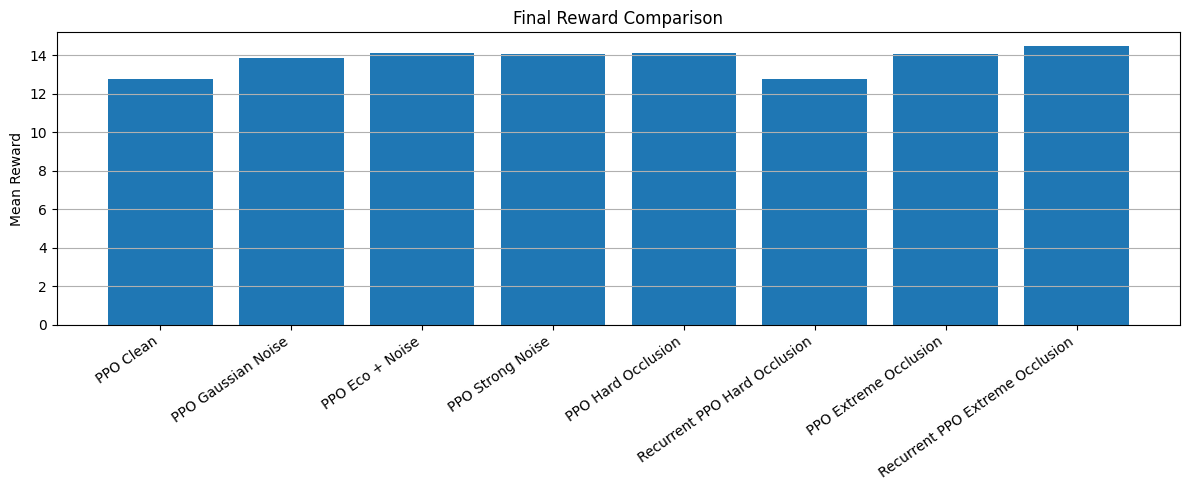

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(final_results["Experiment"], final_results["mean_reward"])
plt.ylabel("Mean Reward")
plt.title("Final Reward Comparison")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("plots/final_reward_comparison.png")
plt.show()

**Collision graph**

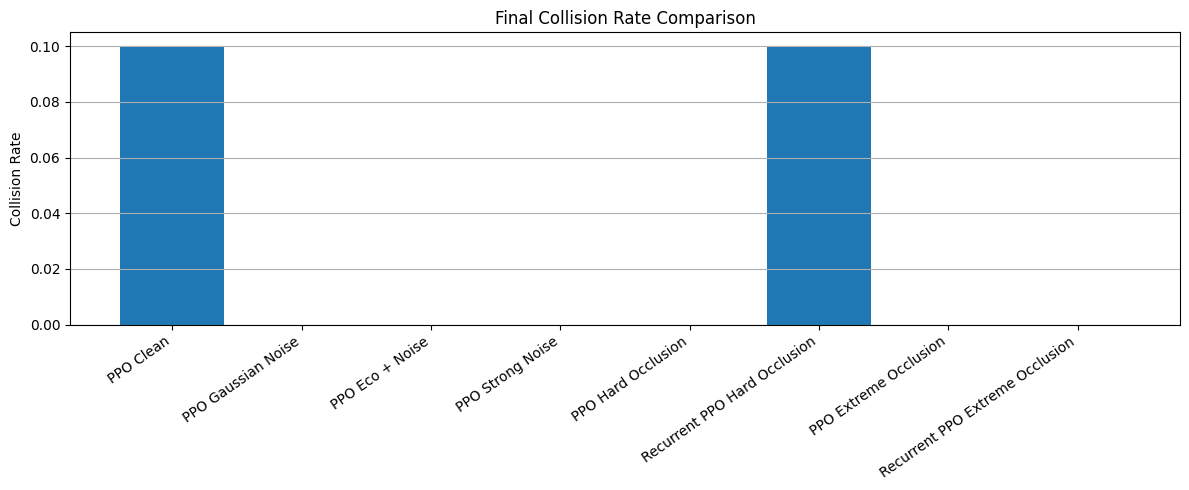

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(final_results["Experiment"], final_results["collision_rate"])
plt.ylabel("Collision Rate")
plt.title("Final Collision Rate Comparison")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("plots/final_collision_comparison.png")
plt.show()

**Learning curves**

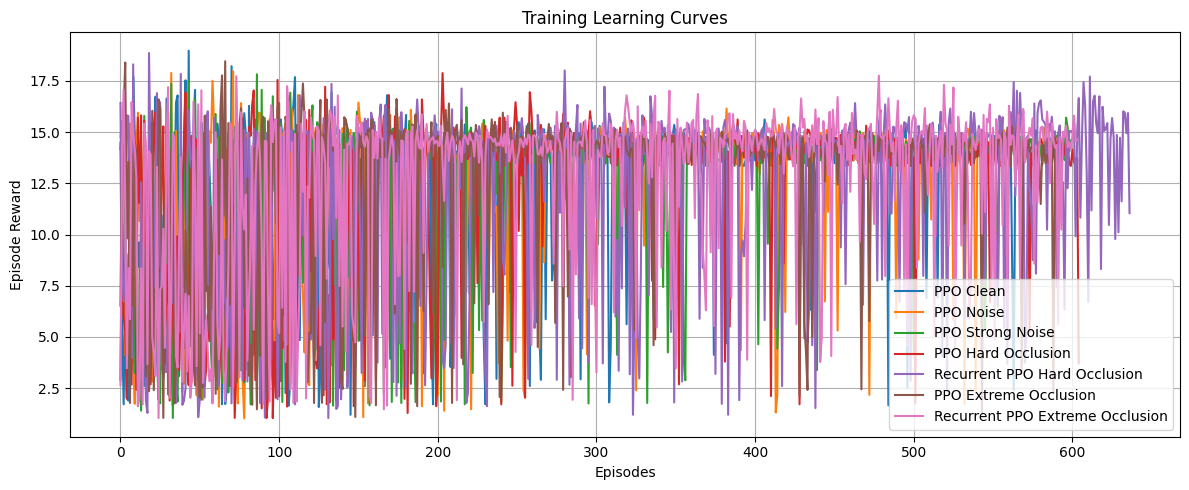

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(rewards_ppo_clean, label="PPO Clean")
plt.plot(rewards_ppo_noise, label="PPO Noise")
plt.plot(rewards_ppo_strong_noise, label="PPO Strong Noise")
plt.plot(rewards_ppo_hard_occlusion, label="PPO Hard Occlusion")
plt.plot(rewards_recurrent_occlusion, label="Recurrent PPO Hard Occlusion")

if "rewards_ppo_extreme_occlusion" in globals():
    plt.plot(rewards_ppo_extreme_occlusion, label="PPO Extreme Occlusion")

if "rewards_lstm_extreme_occlusion" in globals():
    plt.plot(rewards_lstm_extreme_occlusion, label="Recurrent PPO Extreme Occlusion")

plt.xlabel("Episodes")
plt.ylabel("Episode Reward")
plt.title("Training Learning Curves")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("plots/final_learning_curves.png")
plt.show()

# Experiment 10: Long Training Validation (100k Steps)

This experiment validates whether the conclusions observed in shorter runs remain consistent under extended training.

In [ ]:
# =====================================================
# PPO EXTREME OCCLUSION FINAL RUN (100K)
# Use current CPU setup
# =====================================================

env_ppo_100k = make_env(
    vehicle_occlusion=True,
    occlusion_prob=0.95
)

ppo_100k, rewards_ppo_100k = train_ppo(
    env_ppo_100k,
    timesteps=100000,
    name="ppo_extreme_occlusion_100k"
)

results_ppo_100k = evaluate_model(
    ppo_100k,
    env_ppo_100k,
    episodes=20,
    recurrent=False
)

print("\n===== PPO EXTREME OCCLUSION (100K) =====")
print(results_ppo_100k)

results_ppo_100k

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 12.8     |
|    ep_rew_mean     | 9.82     |
| time/              |          |
|    fps             | 44       |
|    iterations      | 1        |
|    time_elapsed    | 11       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 11.9        |
|    ep_rew_mean          | 9.07        |
| time/                   |             |
|    fps                  | 42          |
|    iterations           | 2           |
|    time_elapsed         | 23          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.013509277 |
|    clip_fraction        | 0.13        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.00521    |
|    learning_rate        | 0.0003      |
|    loss                 | 2.68        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0121     |
|    value_loss           | 14.3        |
-----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 18.7        |
|    ep_rew_mean          | 14          |
| time/                   |             |
|    fps                  | 42          |
|    iterations           | 196         |
|    time_elapsed         | 2378        |
|    total_timesteps      | 100352      |
| train/                  |             |
|    approx_kl            | 0.005633345 |
|    clip_fraction        | 0.0695      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.792      |
|    explained_variance   | -0.00745    |
|    learning_rate        | 0.0003      |
|    loss                 | 0.811       |
|    n_updates            | 1950        |
|    policy_gradient_loss | -0.00402    |
|    value_loss           | 34.1        |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



===== PPO EXTREME OCCLUSION (100K) =====
{'mean_reward': np.float64(14.140035163026772), 'std_reward': np.float64(1.0864215407763889), 'collision_rate': 0.05, 'avg_speed': np.float64(20.12986261398349)}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(14.140035163026772),
 'std_reward': np.float64(1.0864215407763889),
 'collision_rate': 0.05,
 'avg_speed': np.float64(20.12986261398349)}

In [ ]:
results_ppo_100k = evaluate_model(
    ppo_100k,
    env_ppo_100k,
    episodes=20,
    recurrent=False
)

print("\n===== FINAL PPO 100K RESULT =====")
print(results_ppo_100k)

results_ppo_100k


===== FINAL PPO 100K RESULT =====
{'mean_reward': np.float64(13.998938623548247), 'std_reward': np.float64(1.6033870376137989), 'collision_rate': 0.05, 'avg_speed': np.float64(20.154486887504913)}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(13.998938623548247),
 'std_reward': np.float64(1.6033870376137989),
 'collision_rate': 0.05,
 'avg_speed': np.float64(20.154486887504913)}

In [ ]:
import os
import pandas as pd

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

ppo_100k.save("models/ppo_extreme_occlusion_100k_final")

ppo_100k_df = pd.DataFrame([{
    "Experiment": "PPO Extreme Occlusion 100k",
    **results_ppo_100k
}])

ppo_100k_df.to_csv("results/ppo_extreme_occlusion_100k_results.csv", index=False)

ppo_100k_df

,Experiment,mean_reward,std_reward,collision_rate,avg_speed
0,PPO Extreme Occlusion 100k,13.998939,1.603387,0.05,20.154487


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
final_project_results = pd.DataFrame([
    {"Experiment": "PPO Clean 10k", "mean_reward": 12.749110, "std_reward": 3.027655, "collision_rate": 0.10, "avg_speed": 19.988295},
    {"Experiment": "PPO Gaussian Noise 10k", "mean_reward": 13.842443, "std_reward": 0.419288, "collision_rate": 0.00, "avg_speed": 20.037915},
    {"Experiment": "PPO Eco + Noise 10k", "mean_reward": 14.109110, "std_reward": 0.400000, "collision_rate": 0.00, "avg_speed": 20.037915},
    {"Experiment": "PPO Strong Noise 10k", "mean_reward": 14.064666, "std_reward": 0.494912, "collision_rate": 0.00, "avg_speed": 20.037915},
    {"Experiment": "PPO Extreme Occlusion 20k", "mean_reward": 14.064666, "std_reward": 0.514482, "collision_rate": 0.00, "avg_speed": 20.037915},
    {"Experiment": "Recurrent PPO Extreme 20k", "mean_reward": 12.359617, "std_reward": 3.878353, "collision_rate": 0.70, "avg_speed": 23.705709},
    {"Experiment": "PPO Extreme Occlusion 100k", **results_ppo_100k},
])

final_project_results

,Experiment,mean_reward,std_reward,collision_rate,avg_speed
0,PPO Clean 10k,12.749110,3.027655,0.10,19.988295
1,PPO Gaussian Noise 10k,13.842443,0.419288,0.00,20.037915
2,PPO Eco + Noise 10k,14.109110,0.400000,0.00,20.037915
3,PPO Strong Noise 10k,14.064666,0.494912,0.00,20.037915
4,PPO Extreme Occlusion 20k,14.064666,0.514482,0.00,20.037915
5,Recurrent PPO Extreme 20k,12.359617,3.878353,0.70,23.705709
6,PPO Extreme Occlusion 100k,13.998939,1.603387,0.05,20.154487


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Experiment 11: Noise Sensitivity Study

This experiment evaluates how PPO performance changes as observation noise increases. Instead of testing only one noisy setting, multiple Gaussian noise levels are evaluated using reward, collision rate, and average speed.


In [ ]:
noise_levels = [0.00, 0.03, 0.05, 0.10, 0.20, 0.40]

noise_sensitivity_results = []
noise_sensitivity_rewards = {}

for noise in noise_levels:
    print(f"\n==============================")
    print(f"Training PPO with Gaussian Noise STD = {noise}")
    print(f"==============================")

    env_noise = make_env(
        gaussian_noise=True if noise > 0 else False,
        noise_std=noise
    )

    model_noise, rewards_noise = train_ppo(
        env_noise,
        timesteps=10000,
        name=f"ppo_noise_std_{str(noise).replace('.', '_')}"
    )

    results_noise = evaluate_model(
        model_noise,
        env_noise,
        episodes=20,
        recurrent=False
    )

    noise_sensitivity_results.append({
        "noise_std": noise,
        **results_noise
    })

    noise_sensitivity_rewards[noise] = rewards_noise

noise_sensitivity_df = pd.DataFrame(noise_sensitivity_results)

noise_sensitivity_df


Training PPO with Gaussian Noise STD = 0.0
Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 10.2     |
|    ep_rew_mean     | 7.81     |
| time/              |          |
|    fps             | 43       |
|    iterations      | 1        |
|    time_elapsed    | 11       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 11.8        |
|    ep_rew_mean          | 9           |
| time/                   |             |
|    fps                  | 42          |
|    iterations           | 2           |
|    time_elapsed         | 24          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.006839862 |
|    clip_fraction        | 0.0598      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | 0.00365     |
|    learning_rate        | 0.0003      |
|    loss                 | 3.25        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00796    |
|    value_loss           | 11.3        |
-----------------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 18.5        |
|    ep_rew_mean          | 13.1        |
| time/                   |             |
|    fps                  | 43          |
|    iterations           | 20          |
|    time_elapsed         | 237         |
|    total_timesteps      | 10240       |
| train/                  |             |
|    approx_kl            | 0.008449313 |
|    clip_fraction        | 0.0814      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.02       |
|    explained_variance   | -0.000415   |
|    learning_rate        | 0.0003      |
|    loss                 | 34.8        |
|    n_updates            | 190         |
|    policy_gradient_loss | -0.0145     |
|    value_loss           | 46.9        |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,noise_std,mean_reward,std_reward,collision_rate,avg_speed
0,0.00,14.020221,0.516398,0.0,20.037915
1,0.03,13.953555,0.428030,0.0,20.037915
2,0.05,14.042443,0.432620,0.0,20.037915
3,0.10,14.461632,1.341349,0.0,20.907227
4,0.20,13.864666,0.428030,0.0,20.037915
5,0.40,13.997999,0.496407,0.0,20.037915


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Save Noise Sensitivity Results**

In [ ]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("plots", exist_ok=True)

noise_sensitivity_df.to_csv(
    "results/noise_sensitivity_results.csv",
    index=False
)

print("Saved: results/noise_sensitivity_results.csv")

noise_sensitivity_df

Saved: results/noise_sensitivity_results.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,noise_std,mean_reward,std_reward,collision_rate,avg_speed
0,0.00,14.020221,0.516398,0.0,20.037915
1,0.03,13.953555,0.428030,0.0,20.037915
2,0.05,14.042443,0.432620,0.0,20.037915
3,0.10,14.461632,1.341349,0.0,20.907227
4,0.20,13.864666,0.428030,0.0,20.037915
5,0.40,13.997999,0.496407,0.0,20.037915


**Mean Reward vs Noise Graph**

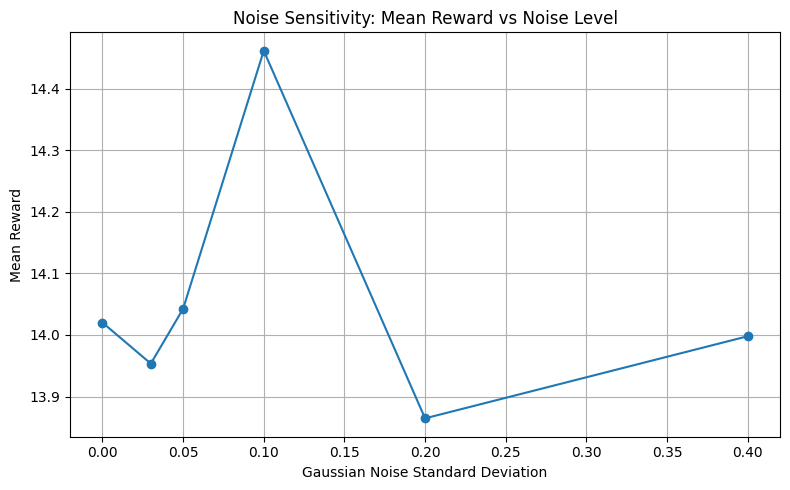

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    noise_sensitivity_df["noise_std"],
    noise_sensitivity_df["mean_reward"],
    marker="o"
)

plt.xlabel("Gaussian Noise Standard Deviation")
plt.ylabel("Mean Reward")
plt.title("Noise Sensitivity: Mean Reward vs Noise Level")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/noise_sensitivity_mean_reward.png")
plt.show()

**Collision Rate vs Noise Graph**

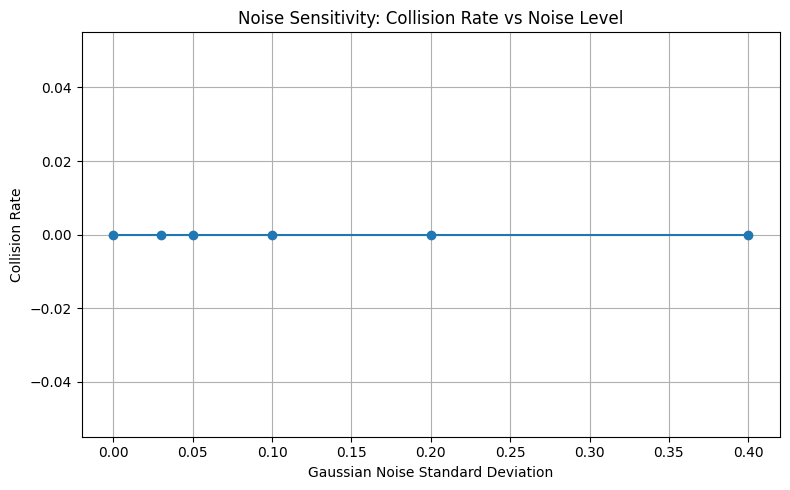

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    noise_sensitivity_df["noise_std"],
    noise_sensitivity_df["collision_rate"],
    marker="o"
)

plt.xlabel("Gaussian Noise Standard Deviation")
plt.ylabel("Collision Rate")
plt.title("Noise Sensitivity: Collision Rate vs Noise Level")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/noise_sensitivity_collision_rate.png")
plt.show()

**Average Speed vs Noise Graph**

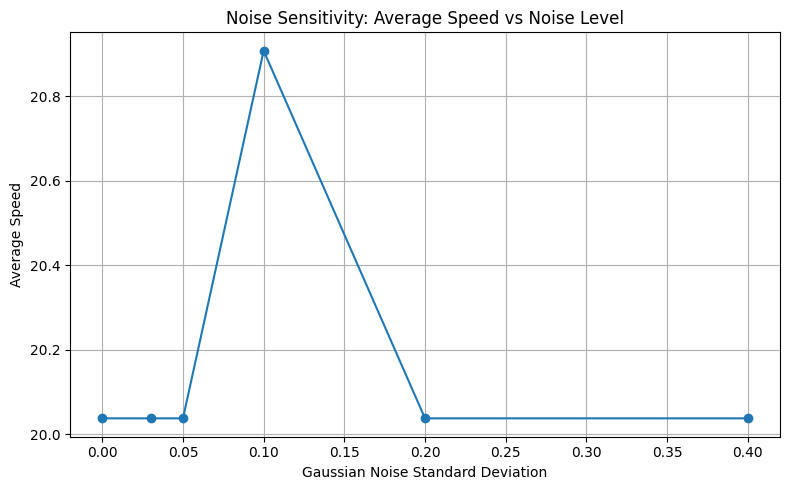

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    noise_sensitivity_df["noise_std"],
    noise_sensitivity_df["avg_speed"],
    marker="o"
)

plt.xlabel("Gaussian Noise Standard Deviation")
plt.ylabel("Average Speed")
plt.title("Noise Sensitivity: Average Speed vs Noise Level")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/noise_sensitivity_avg_speed.png")
plt.show()

# Experiment 12: Occlusion Sensitivity Study

This experiment evaluates the effect of increasing observation loss on policy performance. Vehicle observations are progressively removed to simulate sensor failures and perception blind spots.


In [ ]:
occlusion_levels = [0.00, 0.10, 0.30, 0.50, 0.70, 0.90, 0.95]

occlusion_sensitivity_results = []
occlusion_sensitivity_rewards = {}

for occ in occlusion_levels:
    print(f"\n==============================")
    print(f"Training PPO with Vehicle Occlusion Probability = {occ}")
    print(f"==============================")

    env_occ = make_env(
        vehicle_occlusion=True if occ > 0 else False,
        occlusion_prob=occ
    )

    model_occ, rewards_occ = train_ppo(
        env_occ,
        timesteps=10000,
        name=f"ppo_occlusion_prob_{str(occ).replace('.', '_')}"
    )

    results_occ = evaluate_model(
        model_occ,
        env_occ,
        episodes=20,
        recurrent=False
    )

    occlusion_sensitivity_results.append({
        "occlusion_prob": occ,
        **results_occ
    })

    occlusion_sensitivity_rewards[occ] = rewards_occ

occlusion_sensitivity_df = pd.DataFrame(occlusion_sensitivity_results)

occlusion_sensitivity_df


Training PPO with Vehicle Occlusion Probability = 0.0
Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 11.8     |
|    ep_rew_mean     | 8.87     |
| time/              |          |
|    fps             | 44       |
|    iterations      | 1        |
|    time_elapsed    | 11       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 12.3       |
|    ep_rew_mean          | 9.2        |
| time/                   |            |
|    fps                  | 42         |
|    iterations           | 2          |
|    time_elapsed         | 23         |
|    total_timesteps      | 1024       |
| train/                  |            |
|    approx_kl            | 0.01300934 |
|    clip_fraction        | 0.0885     |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.6       |
|    explained_variance   | 0.00223    |
|    learning_rate        | 0.0003     |
|    loss                 | 4.05       |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.0103    |
|    value_loss           | 10.8       |
----------------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 19.1        |
|    ep_rew_mean          | 13.6        |
| time/                   |             |
|    fps                  | 42          |
|    iterations           | 20          |
|    time_elapsed         | 238         |
|    total_timesteps      | 10240       |
| train/                  |             |
|    approx_kl            | 0.005261427 |
|    clip_fraction        | 0.0453      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.08       |
|    explained_variance   | -0.00196    |
|    learning_rate        | 0.0003      |
|    loss                 | 49          |
|    n_updates            | 190         |
|    policy_gradient_loss | -0.00308    |
|    value_loss           | 40.1        |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,occlusion_prob,mean_reward,std_reward,collision_rate,avg_speed
0,0.00,13.909110,0.523521,0.00,20.037915
1,0.10,13.997999,0.496407,0.00,20.037915
2,0.30,13.782443,1.352695,0.05,20.013791
3,0.50,13.909110,0.504302,0.00,20.037915
4,0.70,13.820221,0.476095,0.00,20.037915
5,0.90,13.997999,0.534720,0.00,20.037915
6,0.95,13.362443,2.263074,0.05,20.014005


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Save Occlusion Sensitivity Results**

In [ ]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("plots", exist_ok=True)

occlusion_sensitivity_df.to_csv(
    "results/occlusion_sensitivity_results.csv",
    index=False
)

print("Saved: results/occlusion_sensitivity_results.csv")

occlusion_sensitivity_df

Saved: results/occlusion_sensitivity_results.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,occlusion_prob,mean_reward,std_reward,collision_rate,avg_speed
0,0.00,13.909110,0.523521,0.00,20.037915
1,0.10,13.997999,0.496407,0.00,20.037915
2,0.30,13.782443,1.352695,0.05,20.013791
3,0.50,13.909110,0.504302,0.00,20.037915
4,0.70,13.820221,0.476095,0.00,20.037915
5,0.90,13.997999,0.534720,0.00,20.037915
6,0.95,13.362443,2.263074,0.05,20.014005


**Mean Reward vs Occlusion Graph**

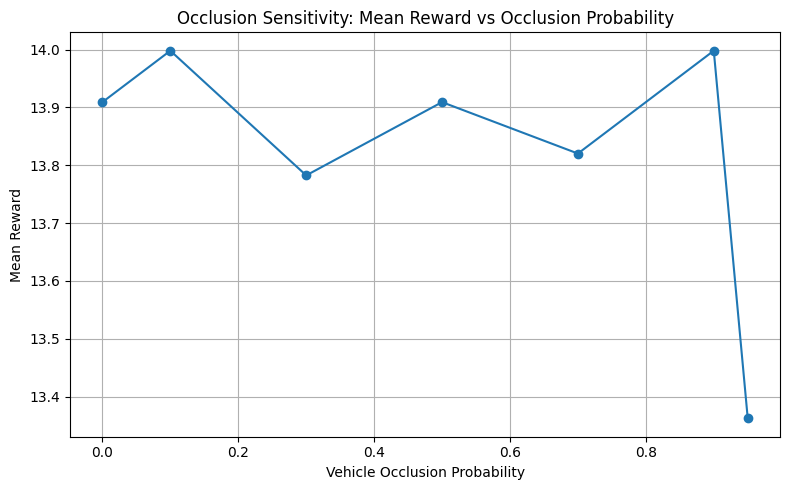

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    occlusion_sensitivity_df["occlusion_prob"],
    occlusion_sensitivity_df["mean_reward"],
    marker="o"
)

plt.xlabel("Vehicle Occlusion Probability")
plt.ylabel("Mean Reward")
plt.title("Occlusion Sensitivity: Mean Reward vs Occlusion Probability")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/occlusion_sensitivity_mean_reward.png")
plt.show()

**Collision Rate vs Occlusion Graph**

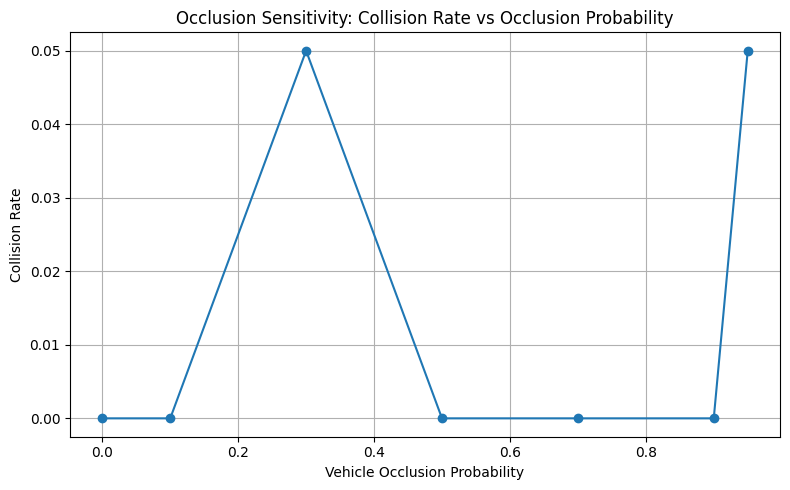

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    occlusion_sensitivity_df["occlusion_prob"],
    occlusion_sensitivity_df["collision_rate"],
    marker="o"
)

plt.xlabel("Vehicle Occlusion Probability")
plt.ylabel("Collision Rate")
plt.title("Occlusion Sensitivity: Collision Rate vs Occlusion Probability")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/occlusion_sensitivity_collision_rate.png")
plt.show()

**Average Speed vs Occlusion Graph**

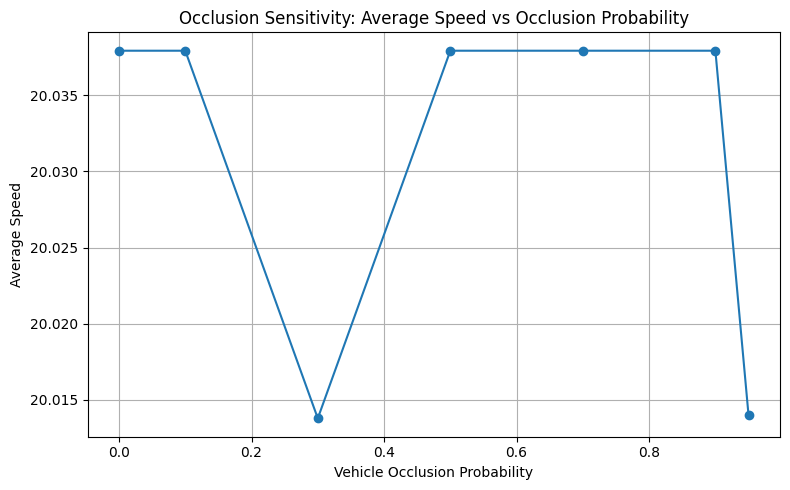

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    occlusion_sensitivity_df["occlusion_prob"],
    occlusion_sensitivity_df["avg_speed"],
    marker="o"
)

plt.xlabel("Vehicle Occlusion Probability")
plt.ylabel("Average Speed")
plt.title("Occlusion Sensitivity: Average Speed vs Occlusion Probability")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/occlusion_sensitivity_avg_speed.png")
plt.show()

# Experiment 13: Recurrent PPO Under Extreme Occlusion (20k Steps)

This experiment evaluates whether a memory-based reinforcement learning agent can improve robustness under severe partial observability. A Recurrent PPO (LSTM) agent is trained for 20,000 timesteps in an environment with extreme vehicle occlusion.

The objective is to determine whether temporal memory helps the agent infer missing information from previous observations and maintain safe driving behavior when surrounding vehicles are frequently hidden from the observation space.

In [ ]:
# =====================================================
# LSTM PPO EXTREME OCCLUSION TEST (20K)
# =====================================================

env_lstm_20k = make_env(
    vehicle_occlusion=True,
    occlusion_prob=0.95
)

lstm_20k, rewards_lstm_20k = train_recurrent_ppo(
    env_lstm_20k,
    timesteps=20000,
    name="lstm_extreme_occlusion_20k"
)

results_lstm_20k = evaluate_model(
    lstm_20k,
    env_lstm_20k,
    episodes=20,
    recurrent=True
)

print("\n===== LSTM PPO EXTREME OCCLUSION (20K) =====")
print(results_lstm_20k)

results_lstm_20k

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 12.4     |
|    ep_rew_mean     | 9.55     |
| time/              |          |
|    fps             | 38       |
|    iterations      | 1        |
|    time_elapsed    | 13       |
|    total_timesteps | 512      |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 11.9        |
|    ep_rew_mean          | 9.07        |
| time/                   |             |
|    fps                  | 29          |
|    iterations           | 2           |
|    time_elapsed         | 34          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.007613929 |
|    clip_fraction        | 0.0967      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | 0.00584     |
|    learning_rate        | 0.0003      |
|    loss                 | 2.84        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00752    |
|    value_loss           | 10.1        |
-----------------------------------------


...

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 18.5       |
|    ep_rew_mean          | 14.3       |
| time/                   |            |
|    fps                  | 23         |
|    iterations           | 40         |
|    time_elapsed         | 860        |
|    total_timesteps      | 20480      |
| train/                  |            |
|    approx_kl            | 0.01329196 |
|    clip_fraction        | 0.124      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.07      |
|    explained_variance   | 0.0132     |
|    learning_rate        | 0.0003     |
|    loss                 | 2.27       |
|    n_updates            | 390        |
|    policy_gradient_loss | -0.00498   |
|    value_loss           | 82         |
----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



===== LSTM PPO EXTREME OCCLUSION (20K) =====
{'mean_reward': np.float64(12.359617364399957), 'std_reward': np.float64(3.878353473477052), 'collision_rate': 0.7, 'avg_speed': np.float64(23.705709029921124)}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


{'mean_reward': np.float64(12.359617364399957),
 'std_reward': np.float64(3.878353473477052),
 'collision_rate': 0.7,
 'avg_speed': np.float64(23.705709029921124)}

# 4. Conclusions

Key Findings:

• PPO is highly robust to Gaussian observation noise.

• Observation occlusion is significantly more challenging than additive noise.

• Recurrent PPO did not outperform PPO under the current training budget.

• PPO maintained stable performance during the 100k-step validation experiment.

• Sensor dropout and missing observations represent a more critical challenge than noisy observations.